In [1]:
#!pip install h5netcdf h5py

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import os
import pandas as pd

In [2]:
import zipfile
import xarray as xr
import io
import rioxarray

In [3]:
import regrid          ## import regrid.py

### ######## Please Modify ############ #

In [4]:
title = "Evapotranspiration (mm/day)"      ########## title of the fig
RfColorMap = 'rainbow'        ######## Color pallete for reference period map

shapeFilePath = './EgypeShapeFile/egy_admbnda_adm1_capmas_20170421.shp'      ### path to tyhe shapefile

## Shape file

<Axes: >

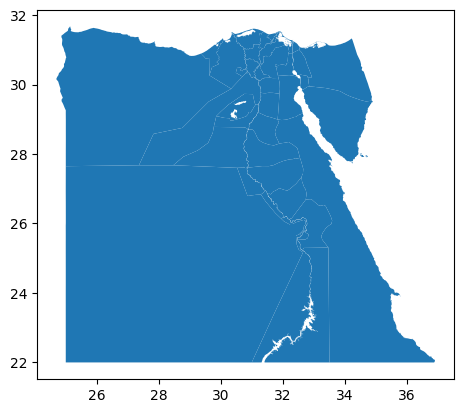

In [5]:
shapeFile = gpd.read_file(shapeFilePath)
shapeFile.plot()

## Load Data

In [7]:
## imoport the script
import withdrawdata 
## Get list of all files
REMOTE_DIR = "/home/regcm/UNDP/rcm-run/Output-RF-SSP126-245-585/RF-SSP-new/LatLon/" 
files = withdrawdata.getListOfData(REMOTE_DIR)
print(files)

['SSP45-SW-2025-2099.nc', 'SSP85-PET-2025-2099.nc', 'SSP85-pr-2025-2099.nc', 'SSP85-SW-2025-2099.nc', 'SSP85-Tmin-2025-2099.nc', 'RF-WS-1995-2014.nc', 'RF-Tmax-1995-2014.nc', 'RF-Tmin-1995-2014.nc', 'SSP26-WSmax-2025-2099.nc', 'SSP26-RH-2025-2099.nc', 'SSP26-sund-2025-2099.nc', 'SSP45-pr-2025-2099.nc', 'SSP45-WS-2025-2099.nc', 'move.bash', 'SSP85-WSmax-2025-2099.nc', 'SSP45-WSmax-2025-2099.nc', 'SSP85-WS-2025-2099.nc', 'RF-PET-1995-2014.nc', 'RF-pr-1995-2014.nc', 'RF-RH-1995-2014.nc', 'RF-sund-1995-2014.nc', 'RF-SW-1995-2014.nc', 'RF.bash', 'SSP26-PET-2025-2099.nc', 'SSP26-pr-2025-2099.nc', 'SSP26-WS-2025-2099.nc', 'SSP26-Tmin-2025-2099.nc', 'SSP26-SW-2025-2099.nc', 'SSP45-Tmin-2025-2099.nc', 'SSP26-Tmax-2025-2099.nc', 'SSP45-RH-2025-2099.nc', 'SSP45-sund-2025-2099.nc', 'SSP45-Tmax-2025-2099.nc', 'SSP85-RH-2025-2099.nc', 'SSP85-sund-2025-2099.nc', 'RF-prmax-1995-2014.nc', 'RF-WSmax-1995-2014.nc', 'SSP.bash', 'SSP26-prmax-2025-2099.nc', 'SSP45-PET-2025-2099.nc', 'SSP45-prmax-2025-2099.n

### ########## Please Modify varNameToWithDraw   ######### #

In [8]:
varNameToWithDraw = 'PET'              ########## name of the variable to withDraw from server

In [10]:
## Load Data
withdrawdata.loadData('./data', [f'RF-{varNameToWithDraw}-1995-2014.nc', f'SSP26-{varNameToWithDraw}-2025-2099.nc',
                                 f'SSP45-{varNameToWithDraw}-2025-2099.nc', f'SSP85-{varNameToWithDraw}-2025-2099.nc'], REMOTE_DIR)

filename RF-PET-1995-2014.nc
filename SSP26-PET-2025-2099.nc
filename SSP45-PET-2025-2099.nc
filename SSP85-PET-2025-2099.nc


()

In [11]:
## open data
Ref = xr.open_dataset(f'./data/RF-{varNameToWithDraw}-1995-2014.nc',decode_times=False)
scenarios = {}
scenarios['ssp26'] = xr.open_dataset(f'./data/SSP26-{varNameToWithDraw}-2025-2099.nc', decode_times=False)   # ssp26
scenarios['ssp45'] = xr.open_dataset(f'./data/SSP45-{varNameToWithDraw}-2025-2099.nc', decode_times=False)   # ssp45
scenarios['ssp85'] = xr.open_dataset(f'./data/SSP85-{varNameToWithDraw}-2025-2099.nc', decode_times=False)   # ssp85

In [14]:
## modify time 
start = "2025-01-01"
def preprocessData(ds, shapeFile):
    ds['time'] = pd.date_range(start=start, periods=len(ds.time), freq='MS')   # Month Start
    ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
    ds = ds.rio.write_crs("EPSG:4326")
    shapeFile = shapeFile.to_crs(ds.rio.crs)
    ds = ds.rio.clip(shapeFile.geometry, shapeFile.crs, drop=True)
    return(ds)
    
scenarios['ssp26'] = preprocessData(scenarios['ssp26'], shapeFile)
scenarios['ssp45'] = preprocessData(scenarios['ssp45'], shapeFile)
scenarios['ssp85'] = preprocessData(scenarios['ssp85'], shapeFile)

In [15]:
start = "1995-01-01"
Ref = preprocessData(Ref, shapeFile)

In [12]:
varName = list(Ref.data_vars)[0]
varName

'pet'

In [31]:
Ref

<xarray.Dataset> Size: 14MB
Dimensions:      (time: 240, lon: 135, lat: 107)
Coordinates:
  * time         (time) datetime64[ns] 2kB 1995-01-01 1995-02-01 ... 2014-12-01
  * lon          (lon) float64 1kB 24.76 24.85 24.94 25.03 ... 36.64 36.73 36.82
  * lat          (lat) float64 856B 22.02 22.11 22.2 22.29 ... 31.38 31.47 31.56
    spatial_ref  int64 8B 0
Data variables:
    pet          (time, lat, lon) float32 14MB nan nan nan 4.224 ... nan nan nan
Attributes: (12/132)
    CDI:                                             Climate Data Interface v...
    Conventions:                                     CF-1.10
    source:                                          RegCM Model output file
    institution:                                     ICTP
    history:                                         Wed Apr 22 09:49:02 2026...
    title:                                           ICTP Regional Climatic m...
    ...                                              ...
    rrtm_cloud_overlap_hypothesis:                   1
    rrtm_mcica_stochastic_cloud:                     1
    rrtm_mcica_stochastic_generator:                 0
    rrtm_nradfo:                                     4
    NCO:                                             netCDF Operators version...
    CDO:                                             Climate Data Operators v...

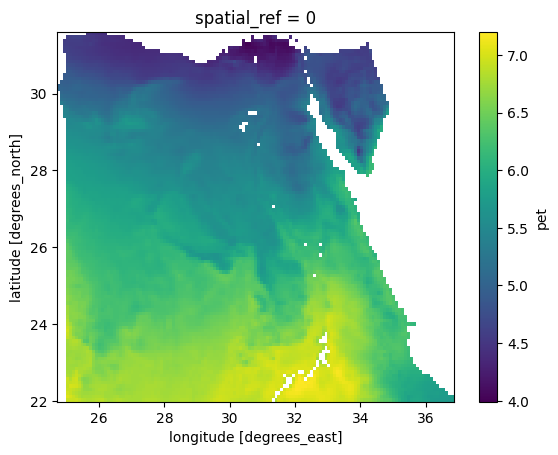

In [16]:
## Get longtermneam of reference period
ltmRef = Ref.mean(dim="time") 
ltmRef['pet'].plot()

## Plot

In [17]:
scenariosSubtitle = ['SSP2.6', 'SSP4.5', 'SSP8.5']
subplotTitles = ['Reference period (Ref)', 'SSP2.5(2025-2030) - Ref', 'SSP4.5(2025-2030) - Ref', 'SSP8.5(2025-2030) - Ref']
cmap = [RfColorMap, 'RdBu_r']

In [18]:
def plotdiff(fig, ds, varName, subtitle, cmap, vmin, vmax, ax, shapeFile):
    ds[varName].plot(vmin=vmin, vmax=vmax, ax=ax, cmap=cmap, cbar_kwargs={
        "orientation": "horizontal",
        "pad": 0.12,
        "shrink": 0.5,
        "format": "%.1f",   
        "label": ""
    })
       
    # Subplot title
    ax.set_title(subtitle, fontsize=14)
    # set individual labels
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("")
    shapeFile.boundary.plot(ax=ax, color='black', linewidth=1)

    return (fig)

        
def adjustFig(fig, period):    
    # Common main title
    fig.suptitle(title, fontsize=16) 
    fig.tight_layout(rect=[0.05, 0.05, 0.9, 0.98]) 
    fig.text(0.12,  0.7,  'Latitude', rotation='vertical', fontsize=12)
    fig.text(0.12,  0.3 , 'Latitude', rotation='vertical', fontsize=12)
    plt.savefig(f"./fig/{period}.png", dpi=600, bbox_inches='tight')
    
    plt.show()
    
    return ()

## Plot figure

In [46]:
def plotData(ltmRef, scenarios, varName, shapFile, StartYear, endYear, vmin, vmax):
    fig, axes = plt.subplots(2, 2, figsize=(12,10))  
    axes = axes.flatten()

    ## Plot ltm of reference period
    fig = plotdiff(fig, ltmRef, varName, 'Ref (1995-2014) ', cmap[0], vmin=np.array(ltmRef[varName].min())-1,
               vmax=np.array(ltmRef[varName].max())+1, ax=axes[0], shapeFile=shapeFile)
    
    ## plot scenaio difference
    for i, scenario in enumerate(scenarios):
        ### Choose the time period
        dScenaio = scenarios[scenario].sel(time=slice(f"{StartYear}-01-01", f'{endYear-1}-12-01'))
        ### calculate the long term mean of reference period
        dScenaio = dScenaio.mean(dim="time") 
        ### calculate the difference between scenario and reference period
        senarioDiff = dScenaio - ltmRef        
        #senario = senario.rio.clip(shapeFile.geometry, shapeFile.crs, drop=True)
        fig = plotdiff(fig, senarioDiff, varName, f'{scenariosSubtitle[i]} ({StartYear}-{endYear-1}) - Ref(1995-2014)', cmap[1], 
                       vmin=vmin,vmax=vmax, ax=axes[i+1], shapeFile=shapeFile)

    adjustFig(fig, StartYear) 
    return()

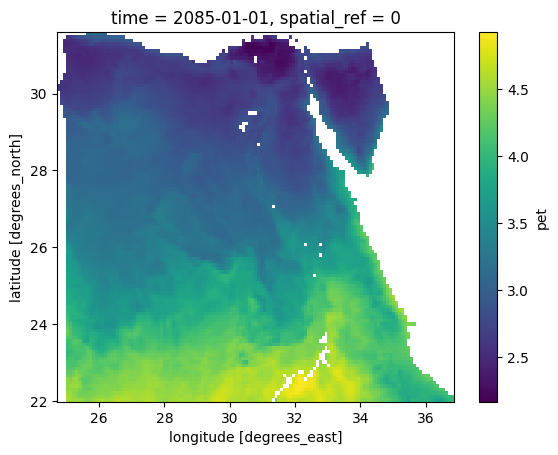

In [36]:
(scenarios['ssp26']['pet'].sel(time="2085-01-01")).plot()

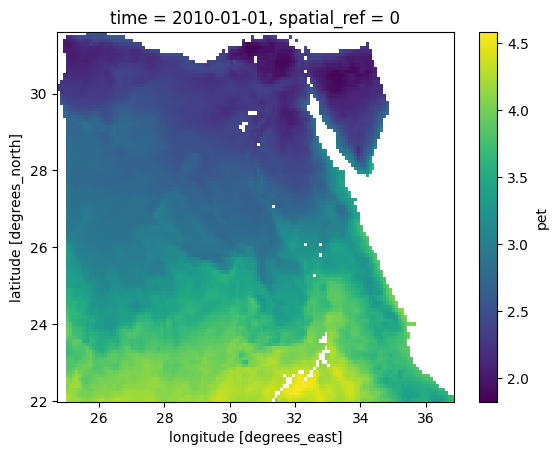

In [33]:
(Ref['pet'].sel(time="2010-01-01")).plot()

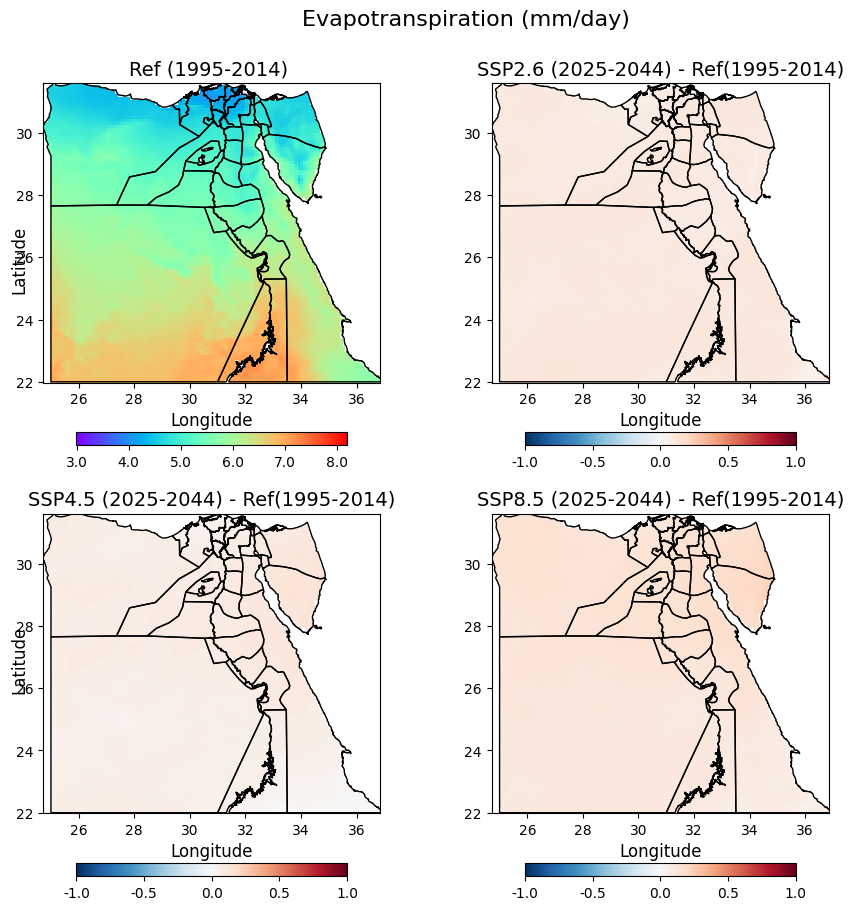

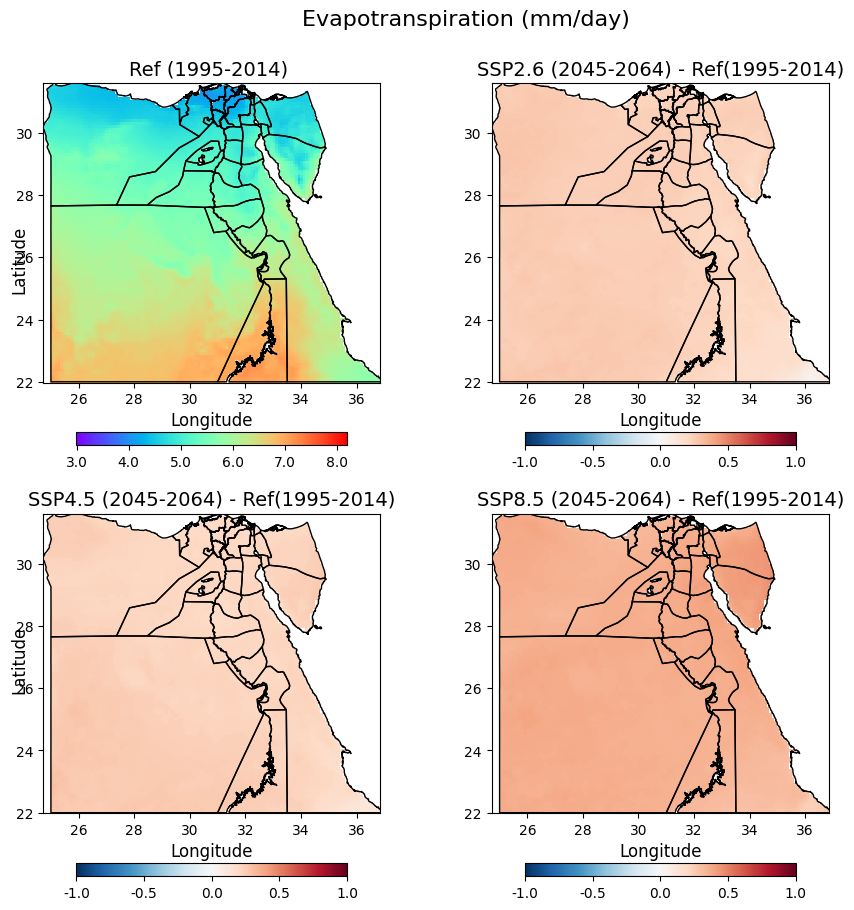

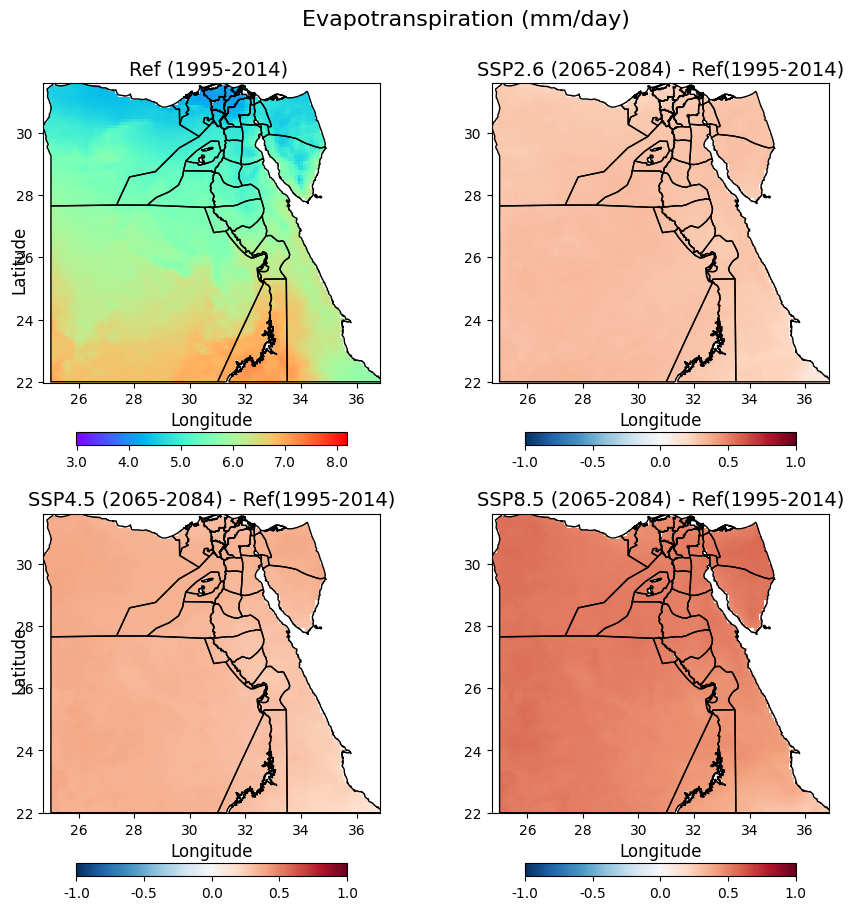

In [47]:
for y in range(2025,2085,20):
    plotData(ltmRef, scenarios, varName, shapeFile, y, y+20, -1, 1)

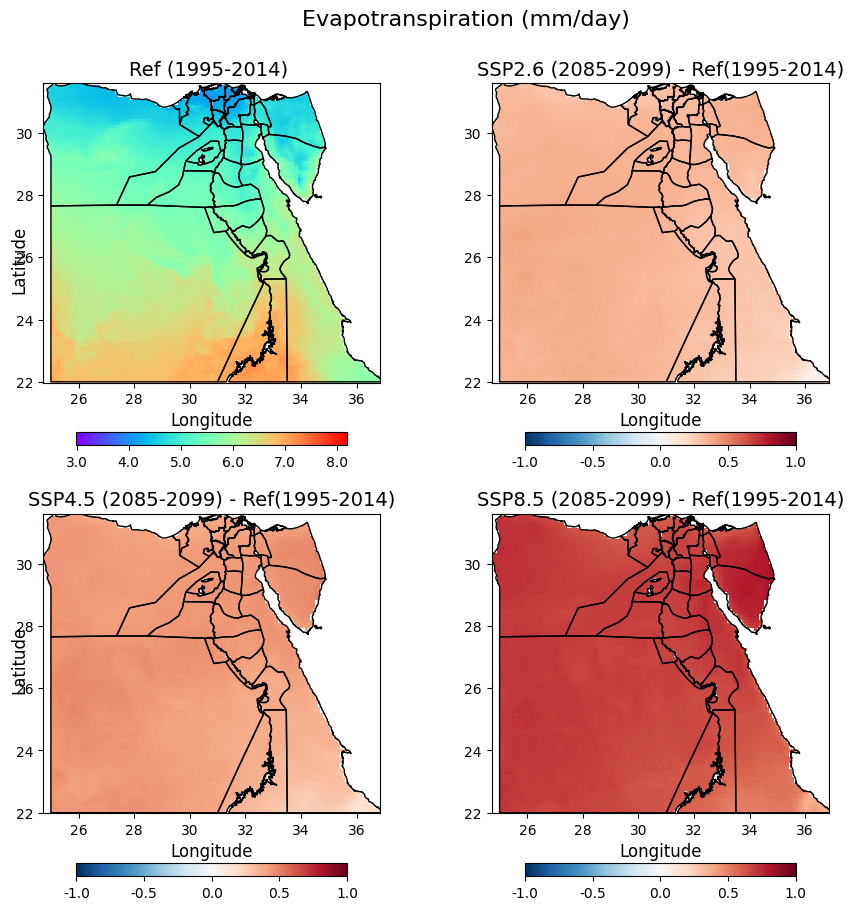

()

In [49]:
plotData(ltmRef, scenarios, varName, shapeFile, 2085, 2100, -1, 1)